# Study Notes: Backpropagation in CNN (Part 1)

---

## Topic 1: Introduction to Backpropagation in CNN

### 1. Introduction

**What it is:**
Backpropagation in CNN is the mathematical process of calculating how changes in each trainable parameter (weights and biases) affect the final loss value. These calculations are then used to update the parameters via gradient descent, gradually minimizing the loss.

**Why it's important:**
Without backpropagation, neural networks cannot learn. It's the engine that drives all training in deep learning. Understanding this process helps you:
- Debug why your model isn't learning
- Make informed decisions about architecture choices
- Use deep learning tools more effectively

**Real-life use:**
Every time you use a CNN for image classification, object detection, face recognition, or medical imaging—backpropagation is working behind the scenes to tune millions of parameters.

**⚠️ Difficulty Warning:**
This is one of the most conceptually difficult topics in deep learning. The math can be challenging. **Watch multiple times** and keep a **copy and pen** handy to work through the calculations yourself.

---

### 2. Detailed Explanation

#### 2.1 The CNN Architecture Used in This Example

Let's consider a simple binary classification CNN:

| Layer | Operation | Input Shape | Output Shape | Trainable Parameters |
|-------|-----------|-------------|--------------|----------------------|
| Input Image | - | 6×6 | 6×6 | 0 |
| Convolution | 3×3 filter, stride=1 | 6×6 | 4×4 | 9 weights + 1 bias (b₁) |
| Activation | ReLU (assumed) | 4×4 | 4×4 | 0 |
| Max Pooling | 2×2, stride=2 | 4×4 | 2×2 | 0 |
| Flatten | - | 2×2 | 4×1 | 0 |
| Fully Connected | Dense layer | 4×1 | 1×1 | 4 weights + 1 bias (b₂) |

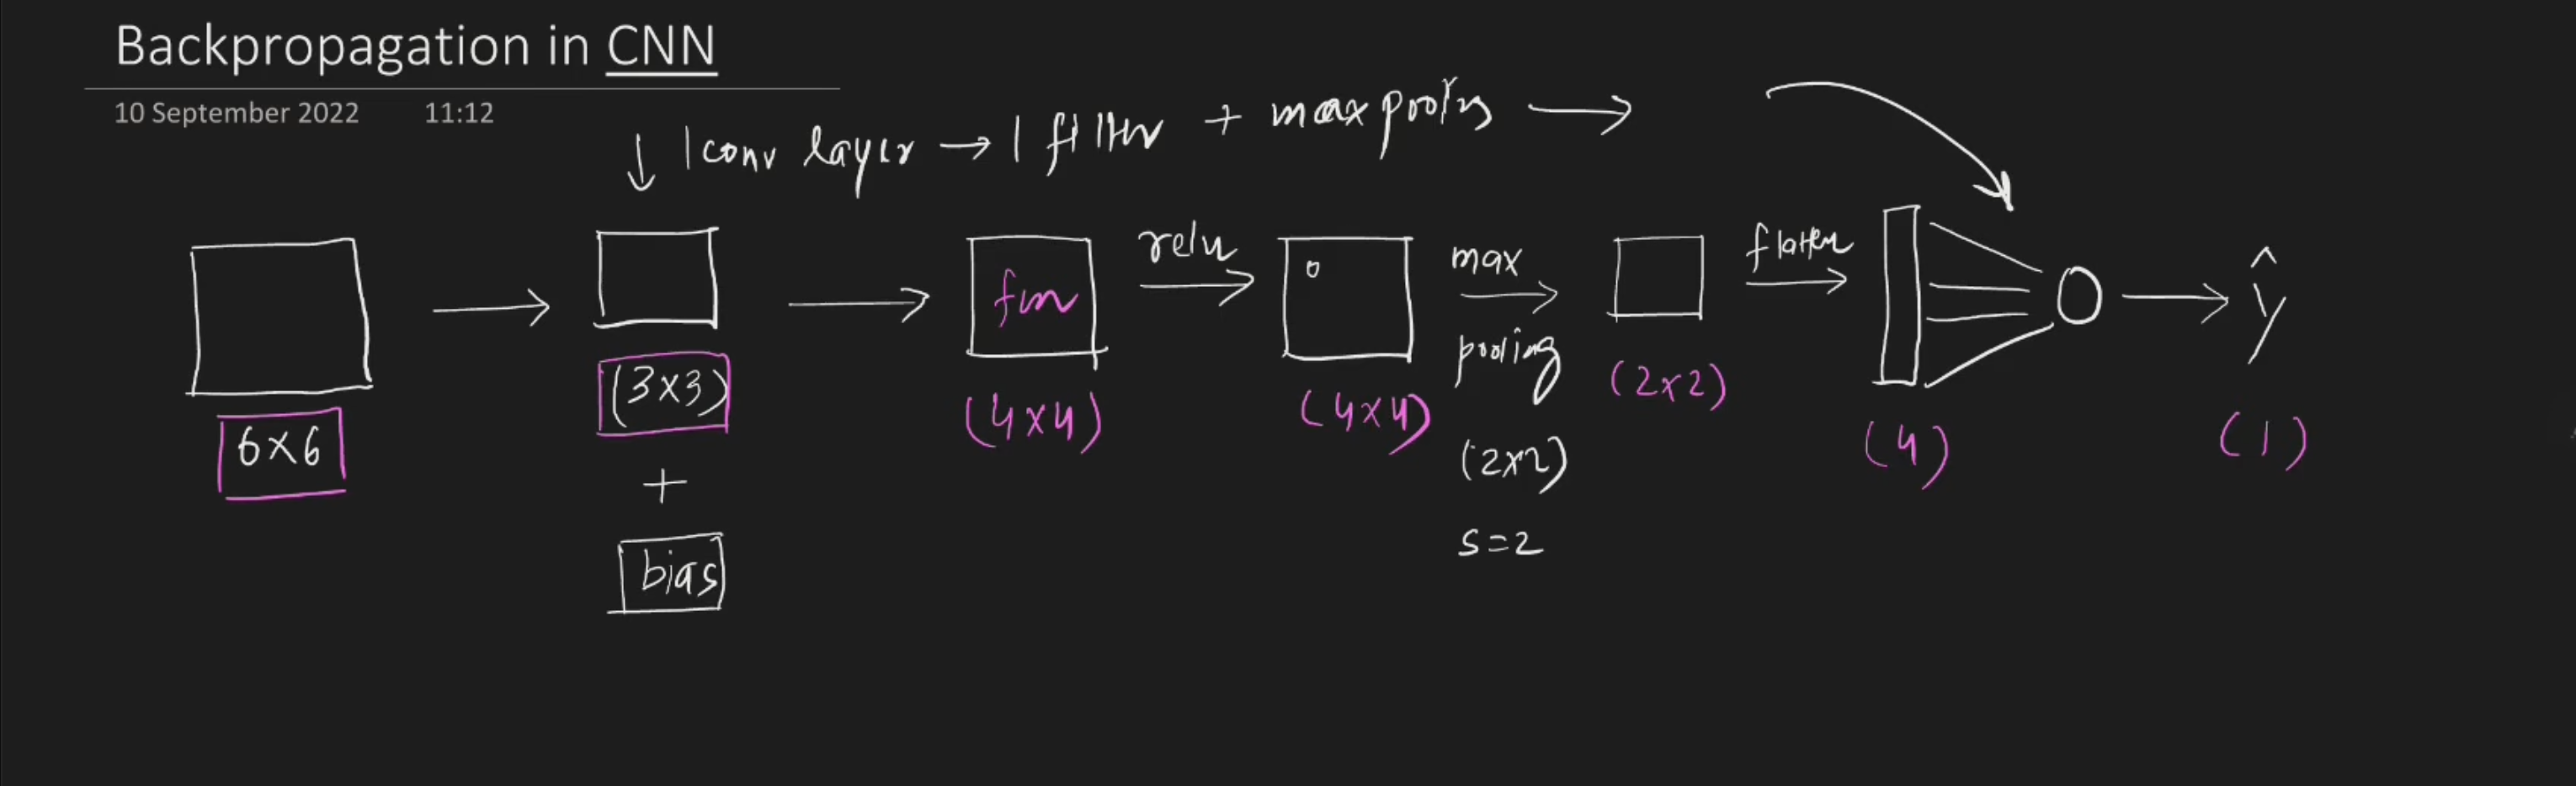

**Total Trainable Parameters:** 9 (w₁) + 1 (b₁) + 4 (w₂) + 1 (b₂) = **15 parameters**
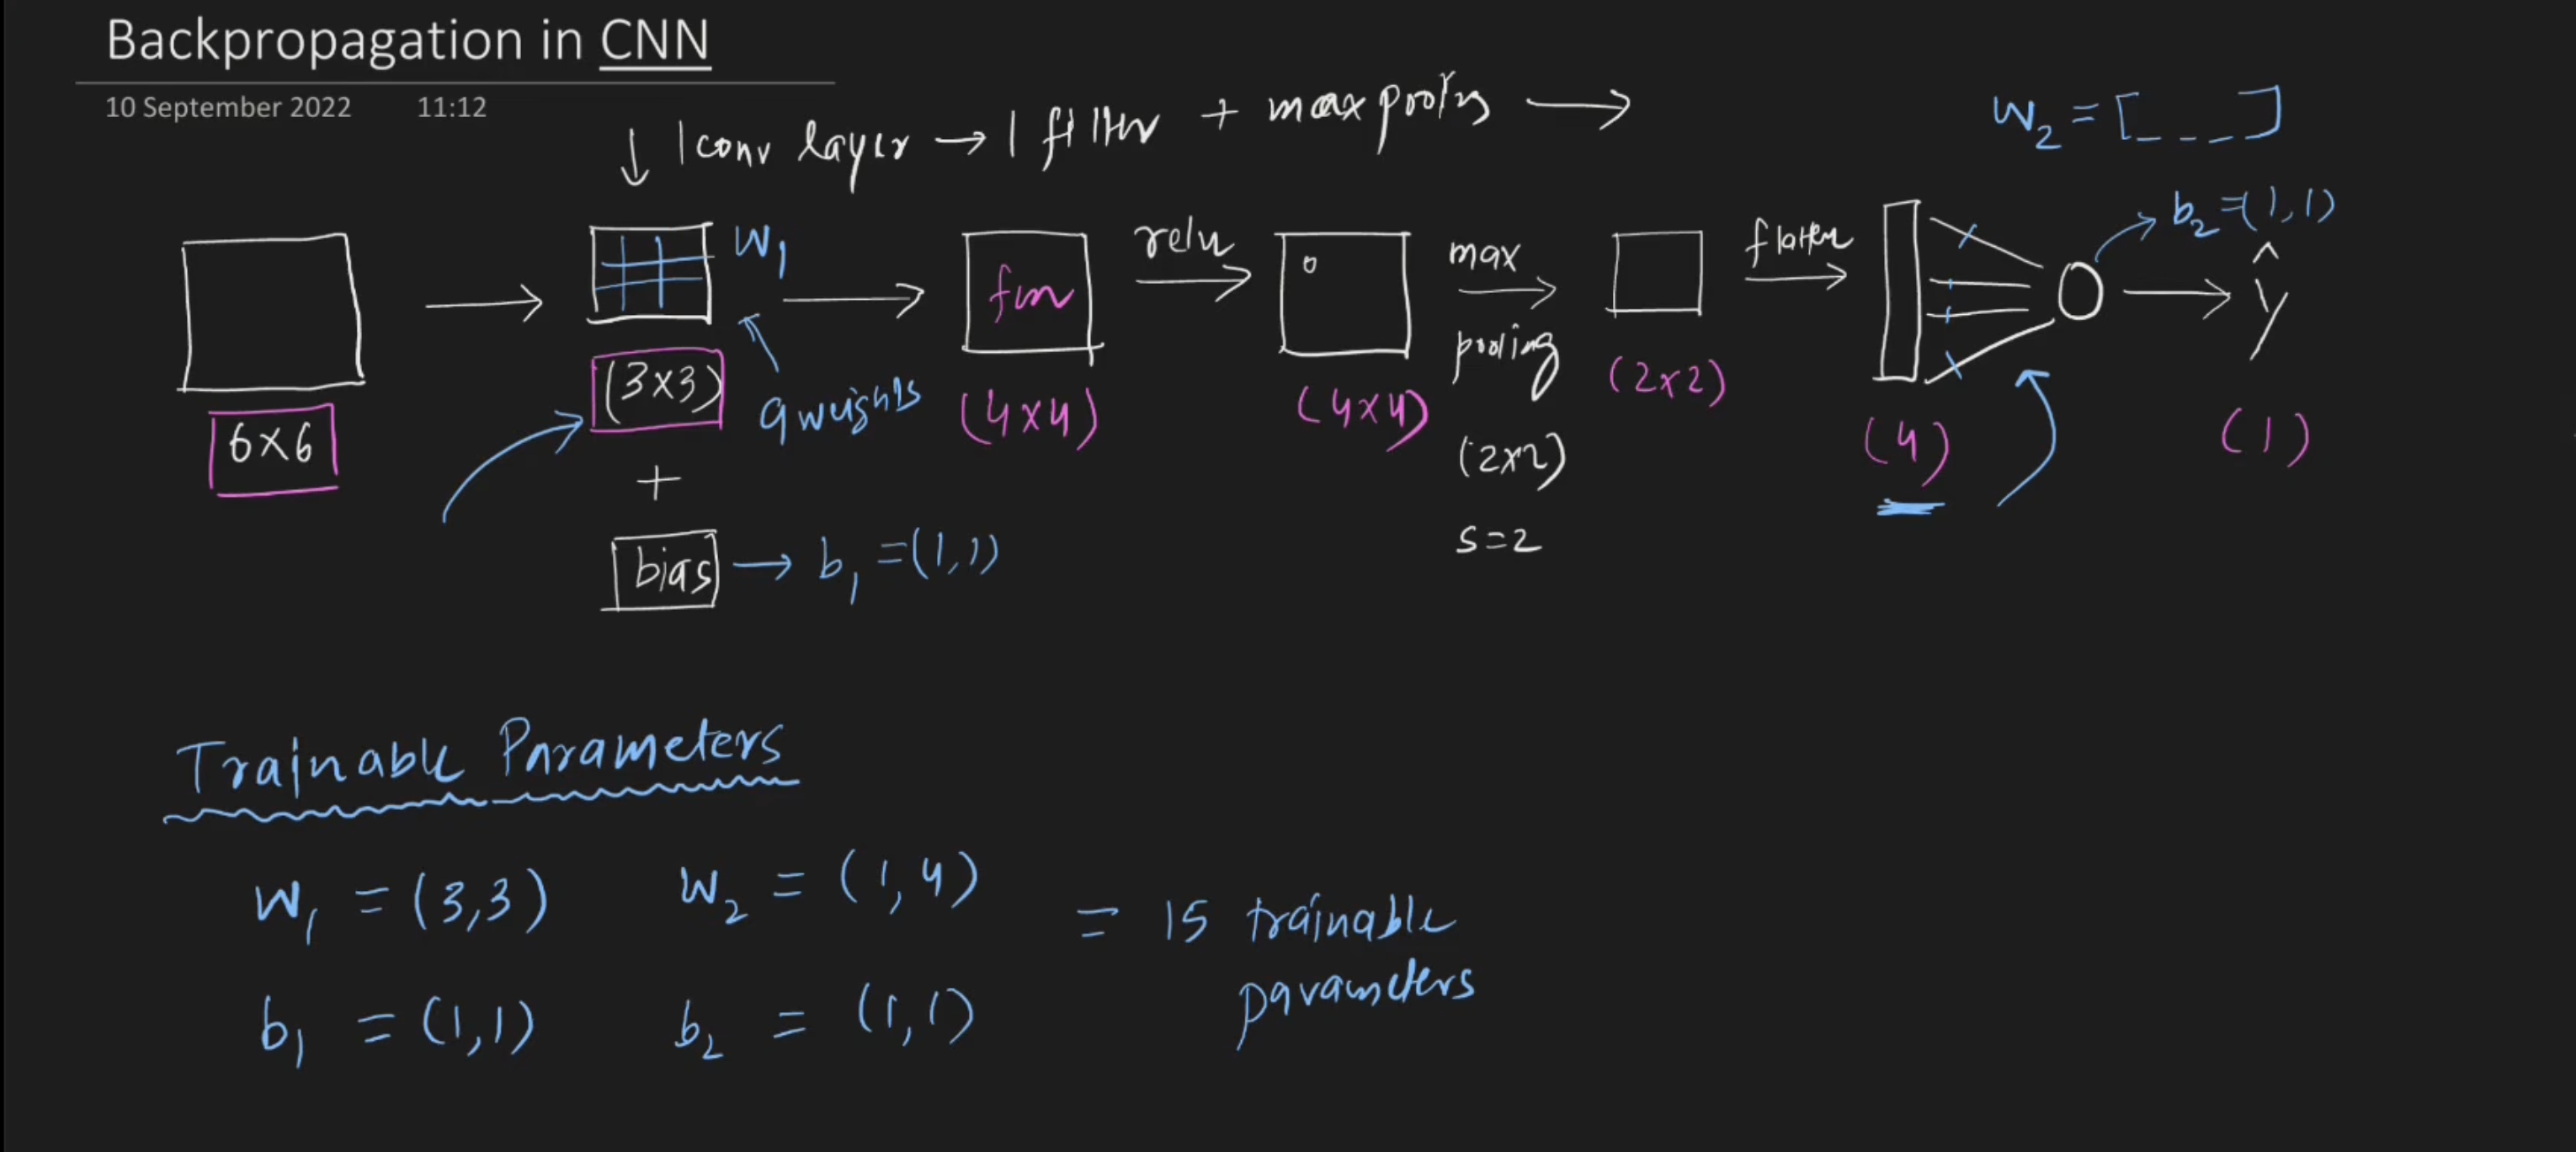

> 💡 **Key Insight:** In this architecture, trainable parameters exist in only TWO places:
> 1. The convolution filter (weights + bias)
> 2. The fully connected layer (weights + bias)

#### 2.2 Binary Classification Setup

- **Problem:** Classify whether an image contains a cat vs. dog
- **Loss Function:** Binary Cross-Entropy
  - For a single instance: `L = -[y·log(ŷ) + (1-y)·log(1-ŷ)]`
  - For a batch: Average loss over all images

#### 2.3 Forward Propagation Flow (Logical Diagram)

```
X (Input Image)
    ↓
Convolution with W₁ + b₁
    ↓
Z₁ (Pre-activation)
    ↓
ReLU Activation
    ↓
A₁ (Post-activation)
    ↓
Max Pooling
    ↓
P₁ (Pooled output)
    ↓
Flatten
    ↓
F (Flattened vector)
    ↓
Fully Connected: F · W₂ + b₂
    ↓
Z₂ (Pre-activation)
    ↓
Sigmoid Activation
    ↓
A₂ (Prediction ŷ)
    ↓
Loss Calculation
    ↓
L (Loss value)
```
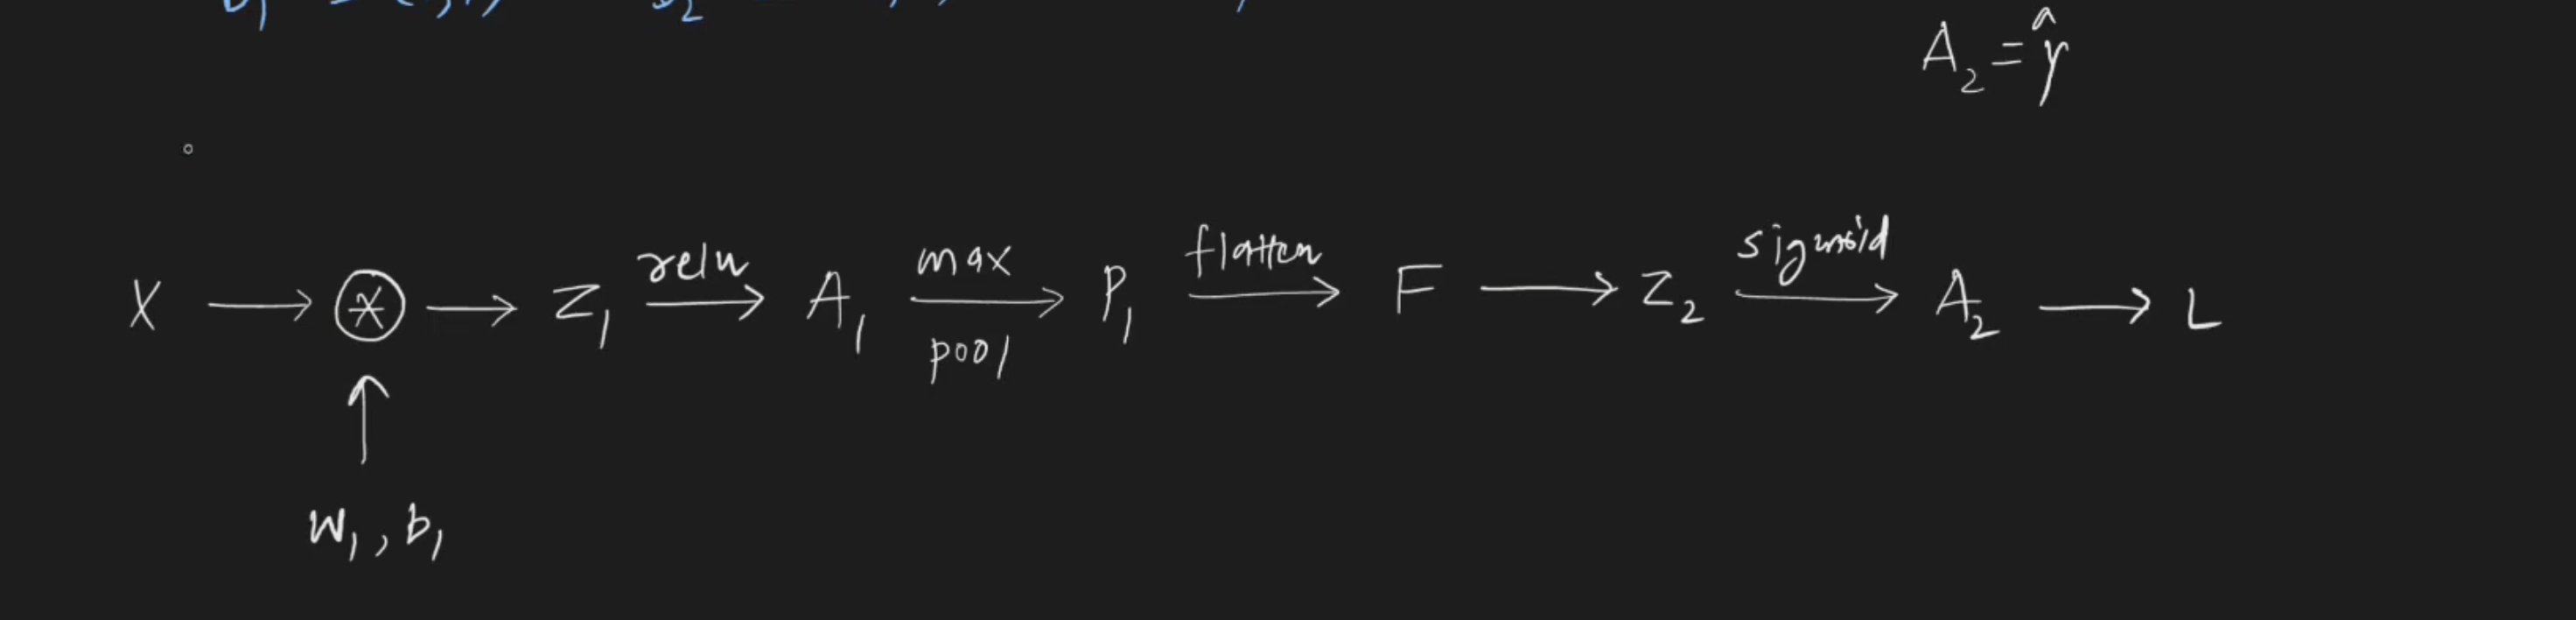
#### 2.4 Forward Propagation Equations
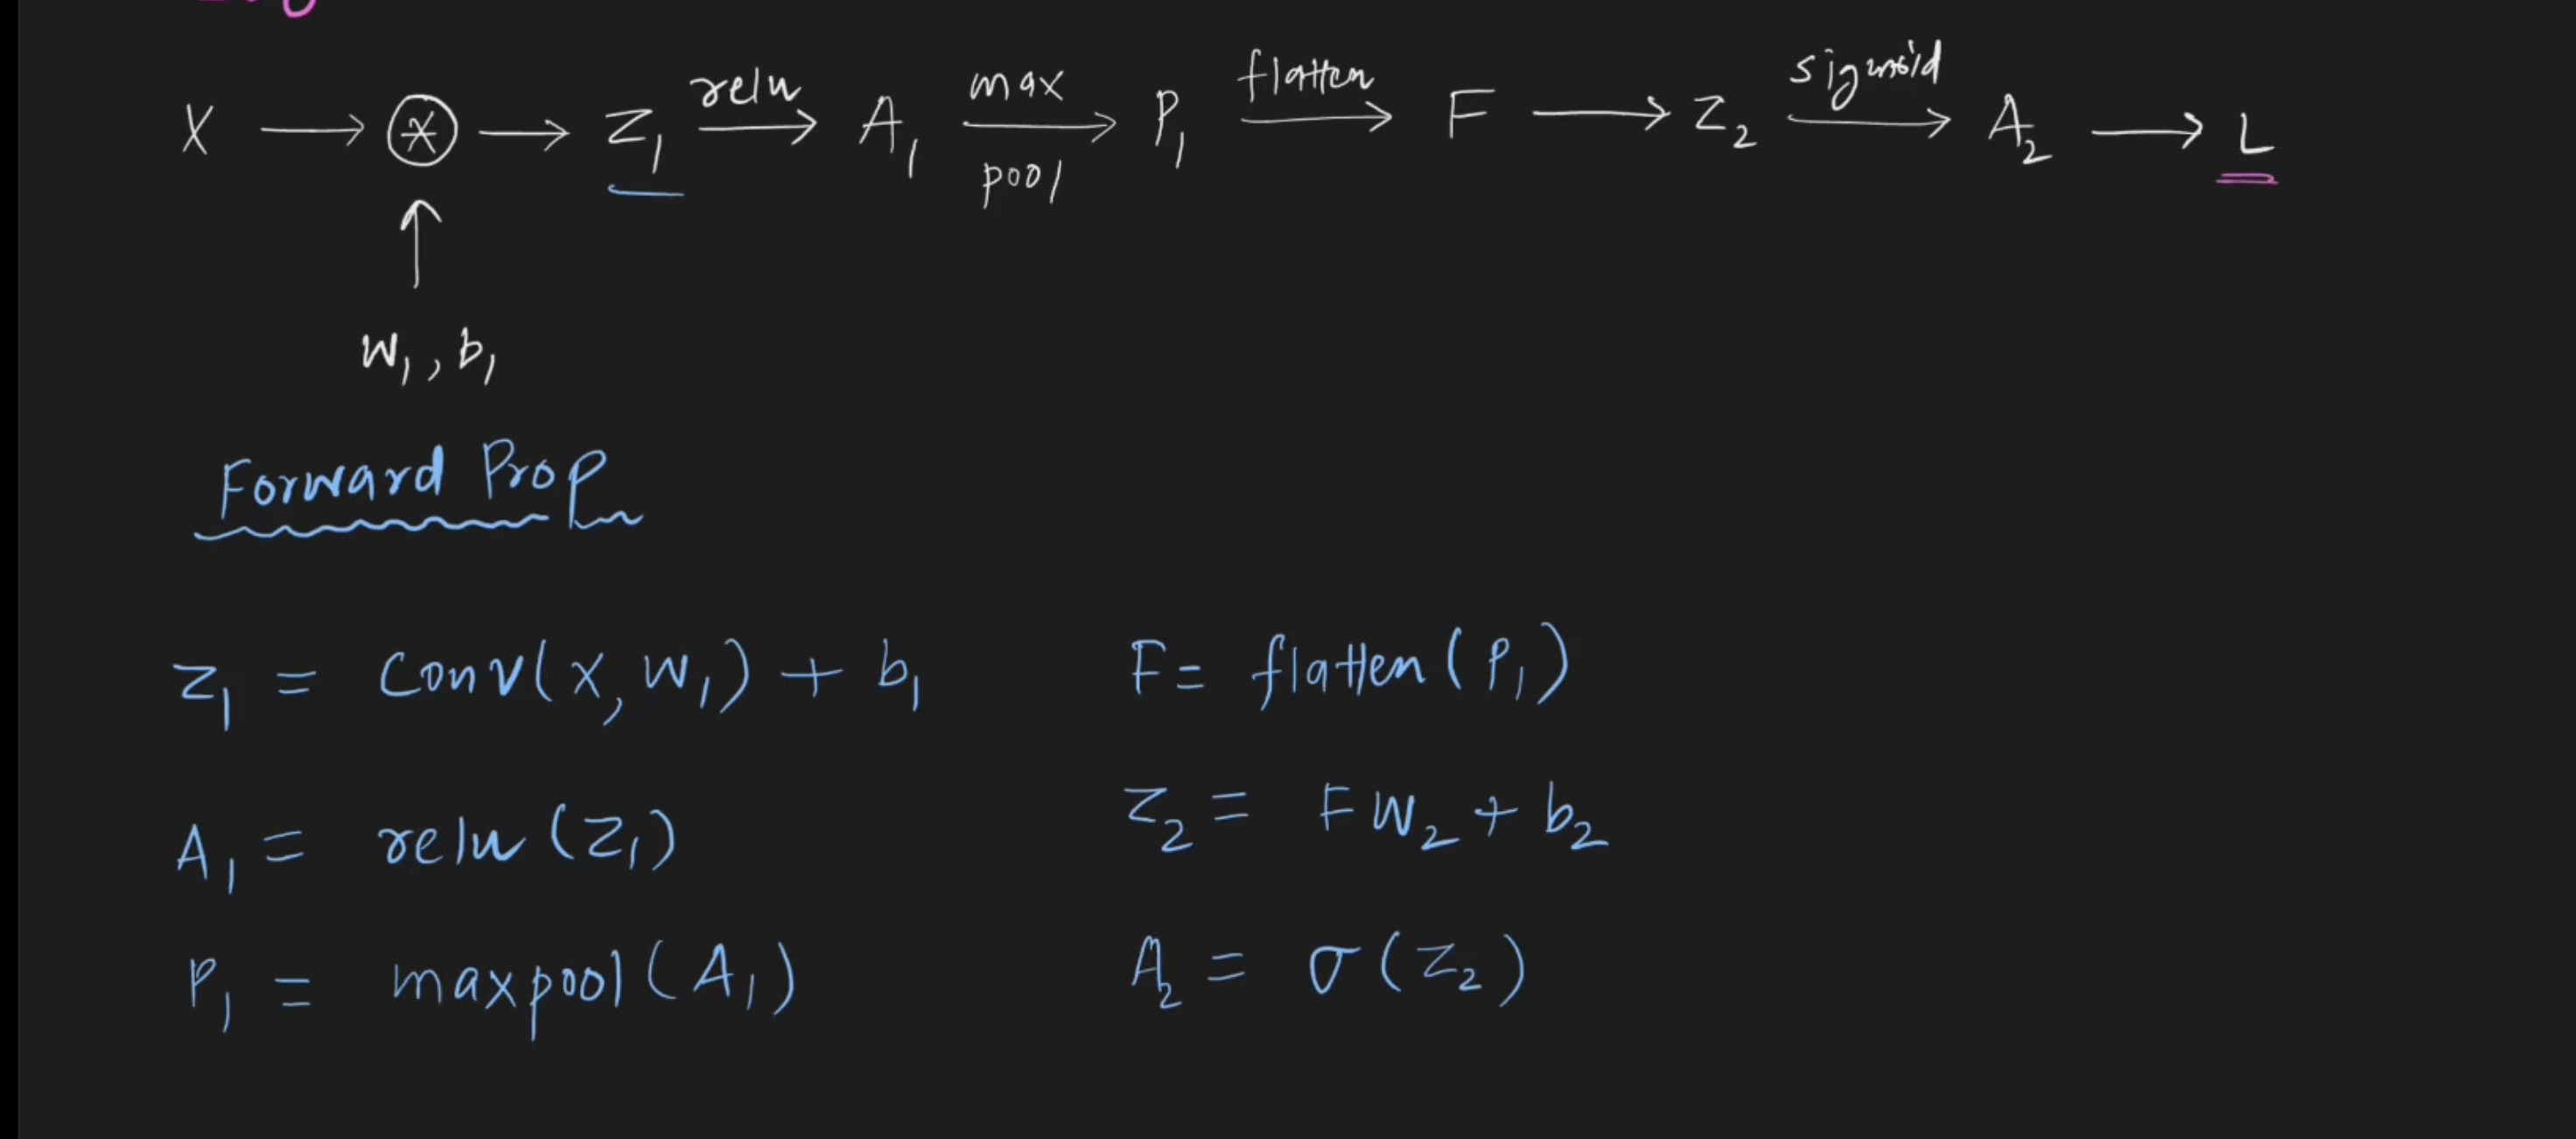
**Equation 1:** `Z₁ = convolution(X, W₁) + b₁`

**Equation 2:** `A₁ = ReLU(Z₁)`

**Equation 3:** `P₁ = MaxPool(A₁)`

**Equation 4:** `F = flatten(P₁)` — Shape becomes (4×1)

**Equation 5:** `Z₂ = F · W₂ + b₂`

**Equation 6:** `A₂ = σ(Z₂)` — where σ is sigmoid activation

**Equation 7:** `L = -[y·log(A₂) + (1-y)·log(1-A₂)]`


---

### 3. Key Points

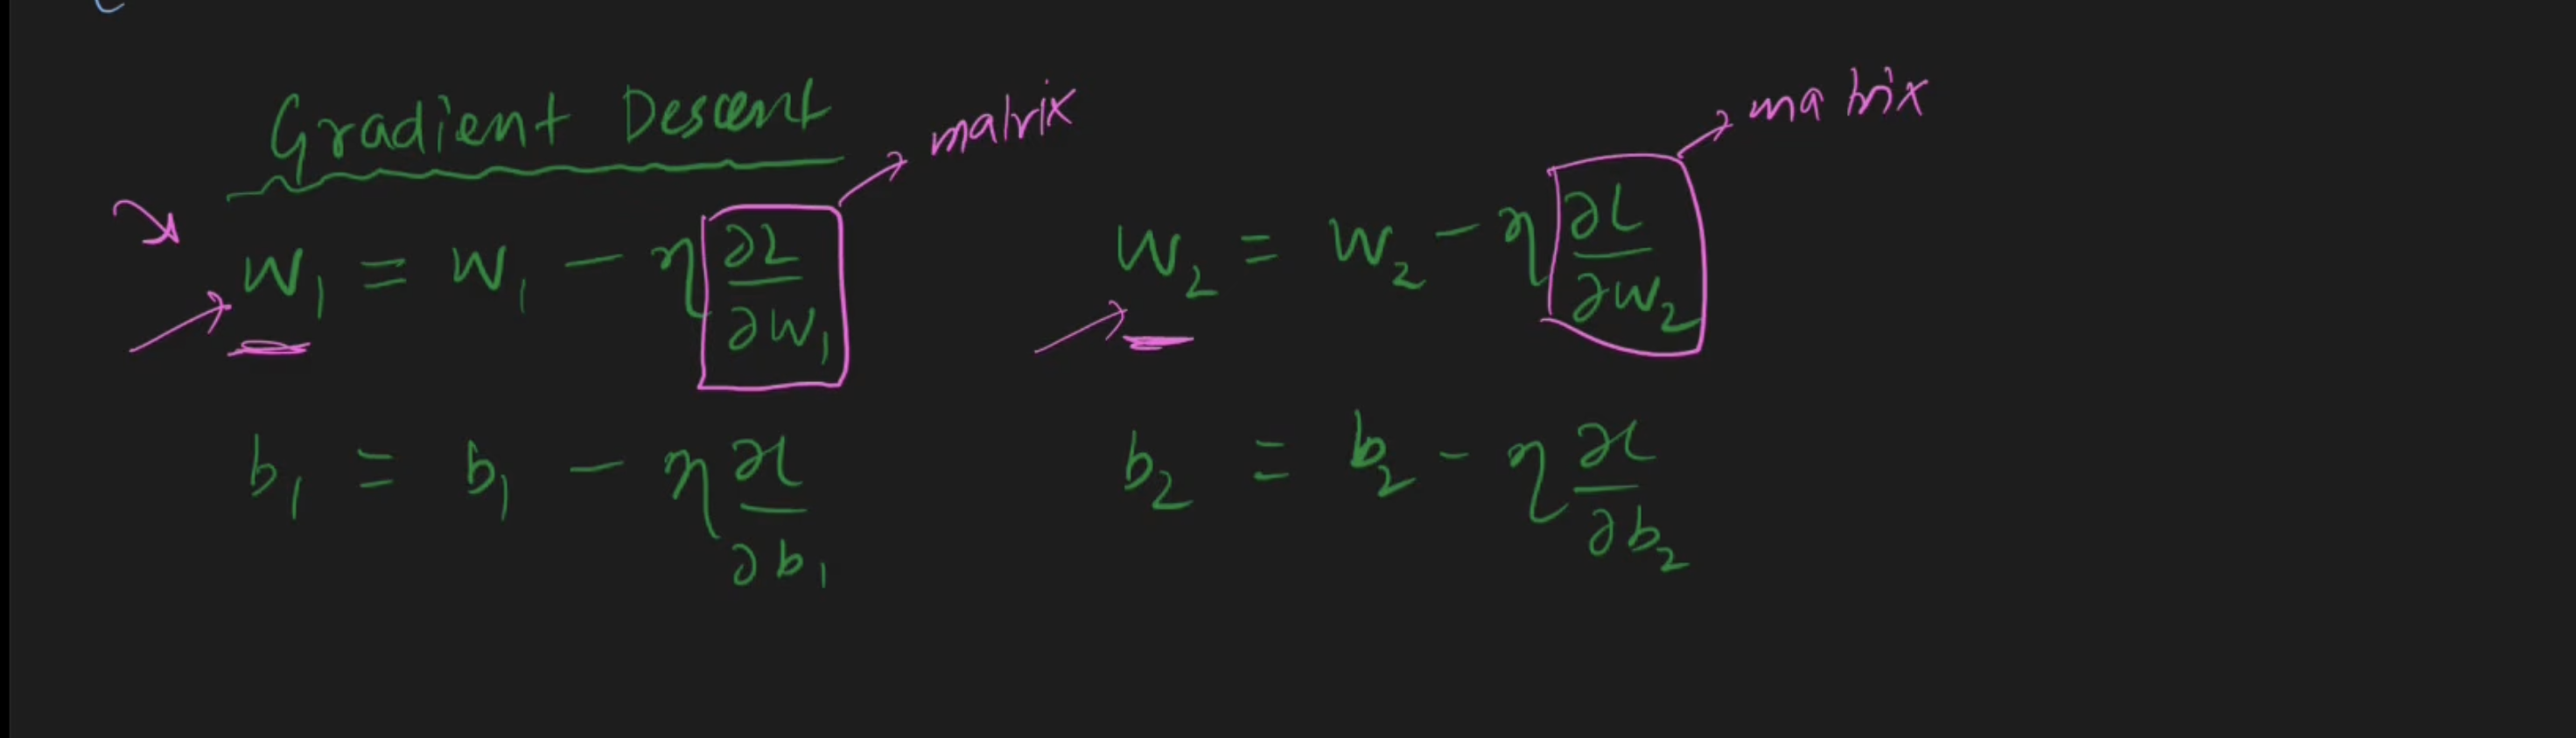

- ✅ Backpropagation calculates **derivatives** of loss w.r.t. each parameter
- ✅ Gradient descent uses these derivatives to **update** parameters
- ✅ The goal: find optimal parameter values that **minimize loss**
- ✅ CNN architecture is divided into **two parts** for easier understanding:
  - **Part 1:** Convolution → Activation → Pooling
  - **Part 2:** Flatten → Fully Connected → Output
- ✅ Total parameters = 15 in this example
- ✅ Parameters only exist at **convolution layer** and **fully connected layer**

---

### 4. Common Mistakes

| ❌ Mistake | ✅ How to Avoid |
|------------|-----------------|
| Confusing shapes of derivatives | Always track matrix/vector shapes carefully |
| Forgetting that W₁ is a matrix | Derivatives w.r.t. W₁ will also be a matrix |
| Applying backpropagation formulas from standard neural networks directly | CNN backpropagation requires special handling for convolution and pooling |
| Not drawing the architecture first | Always sketch the logical flow before attempting derivatives |
| Giving up because math looks hard | Break it down step-by-step, watch videos multiple times |

---

### 5. Interview/Exam Questions

**Q1: Where are the trainable parameters located in a typical CNN architecture?**

**A:** Trainable parameters are located only at layers that have weights and biases:
- Convolution layers (filter weights + bias)
- Fully connected/dense layers (weights + bias)
- Pooling, activation, and flatten layers have NO trainable parameters

---

**Q2: Why is backpropagation important in deep learning?**

**A:** Backpropagation calculates gradients (derivatives) of the loss with respect to all trainable parameters. These gradients tell us how to adjust each parameter to reduce the loss. Without backpropagation, we couldn't train neural networks effectively.

---

**Q3: What is the total number of trainable parameters in the example architecture? (6×6 input, 3×3 filter, 4-input FC layer)**

**A:** 
- Convolution layer: 3×3 = 9 weights + 1 bias = 10
- Fully connected layer: 4 weights + 1 bias = 5
- **Total = 15 parameters**

---

**Q4: How does the loss function differ for binary vs. multi-class classification?**

**A:**
- **Binary:** Binary Cross-Entropy with sigmoid activation at output
- **Multi-class:** Categorical Cross-Entropy with softmax activation at output

---

### 6. Revision Notes
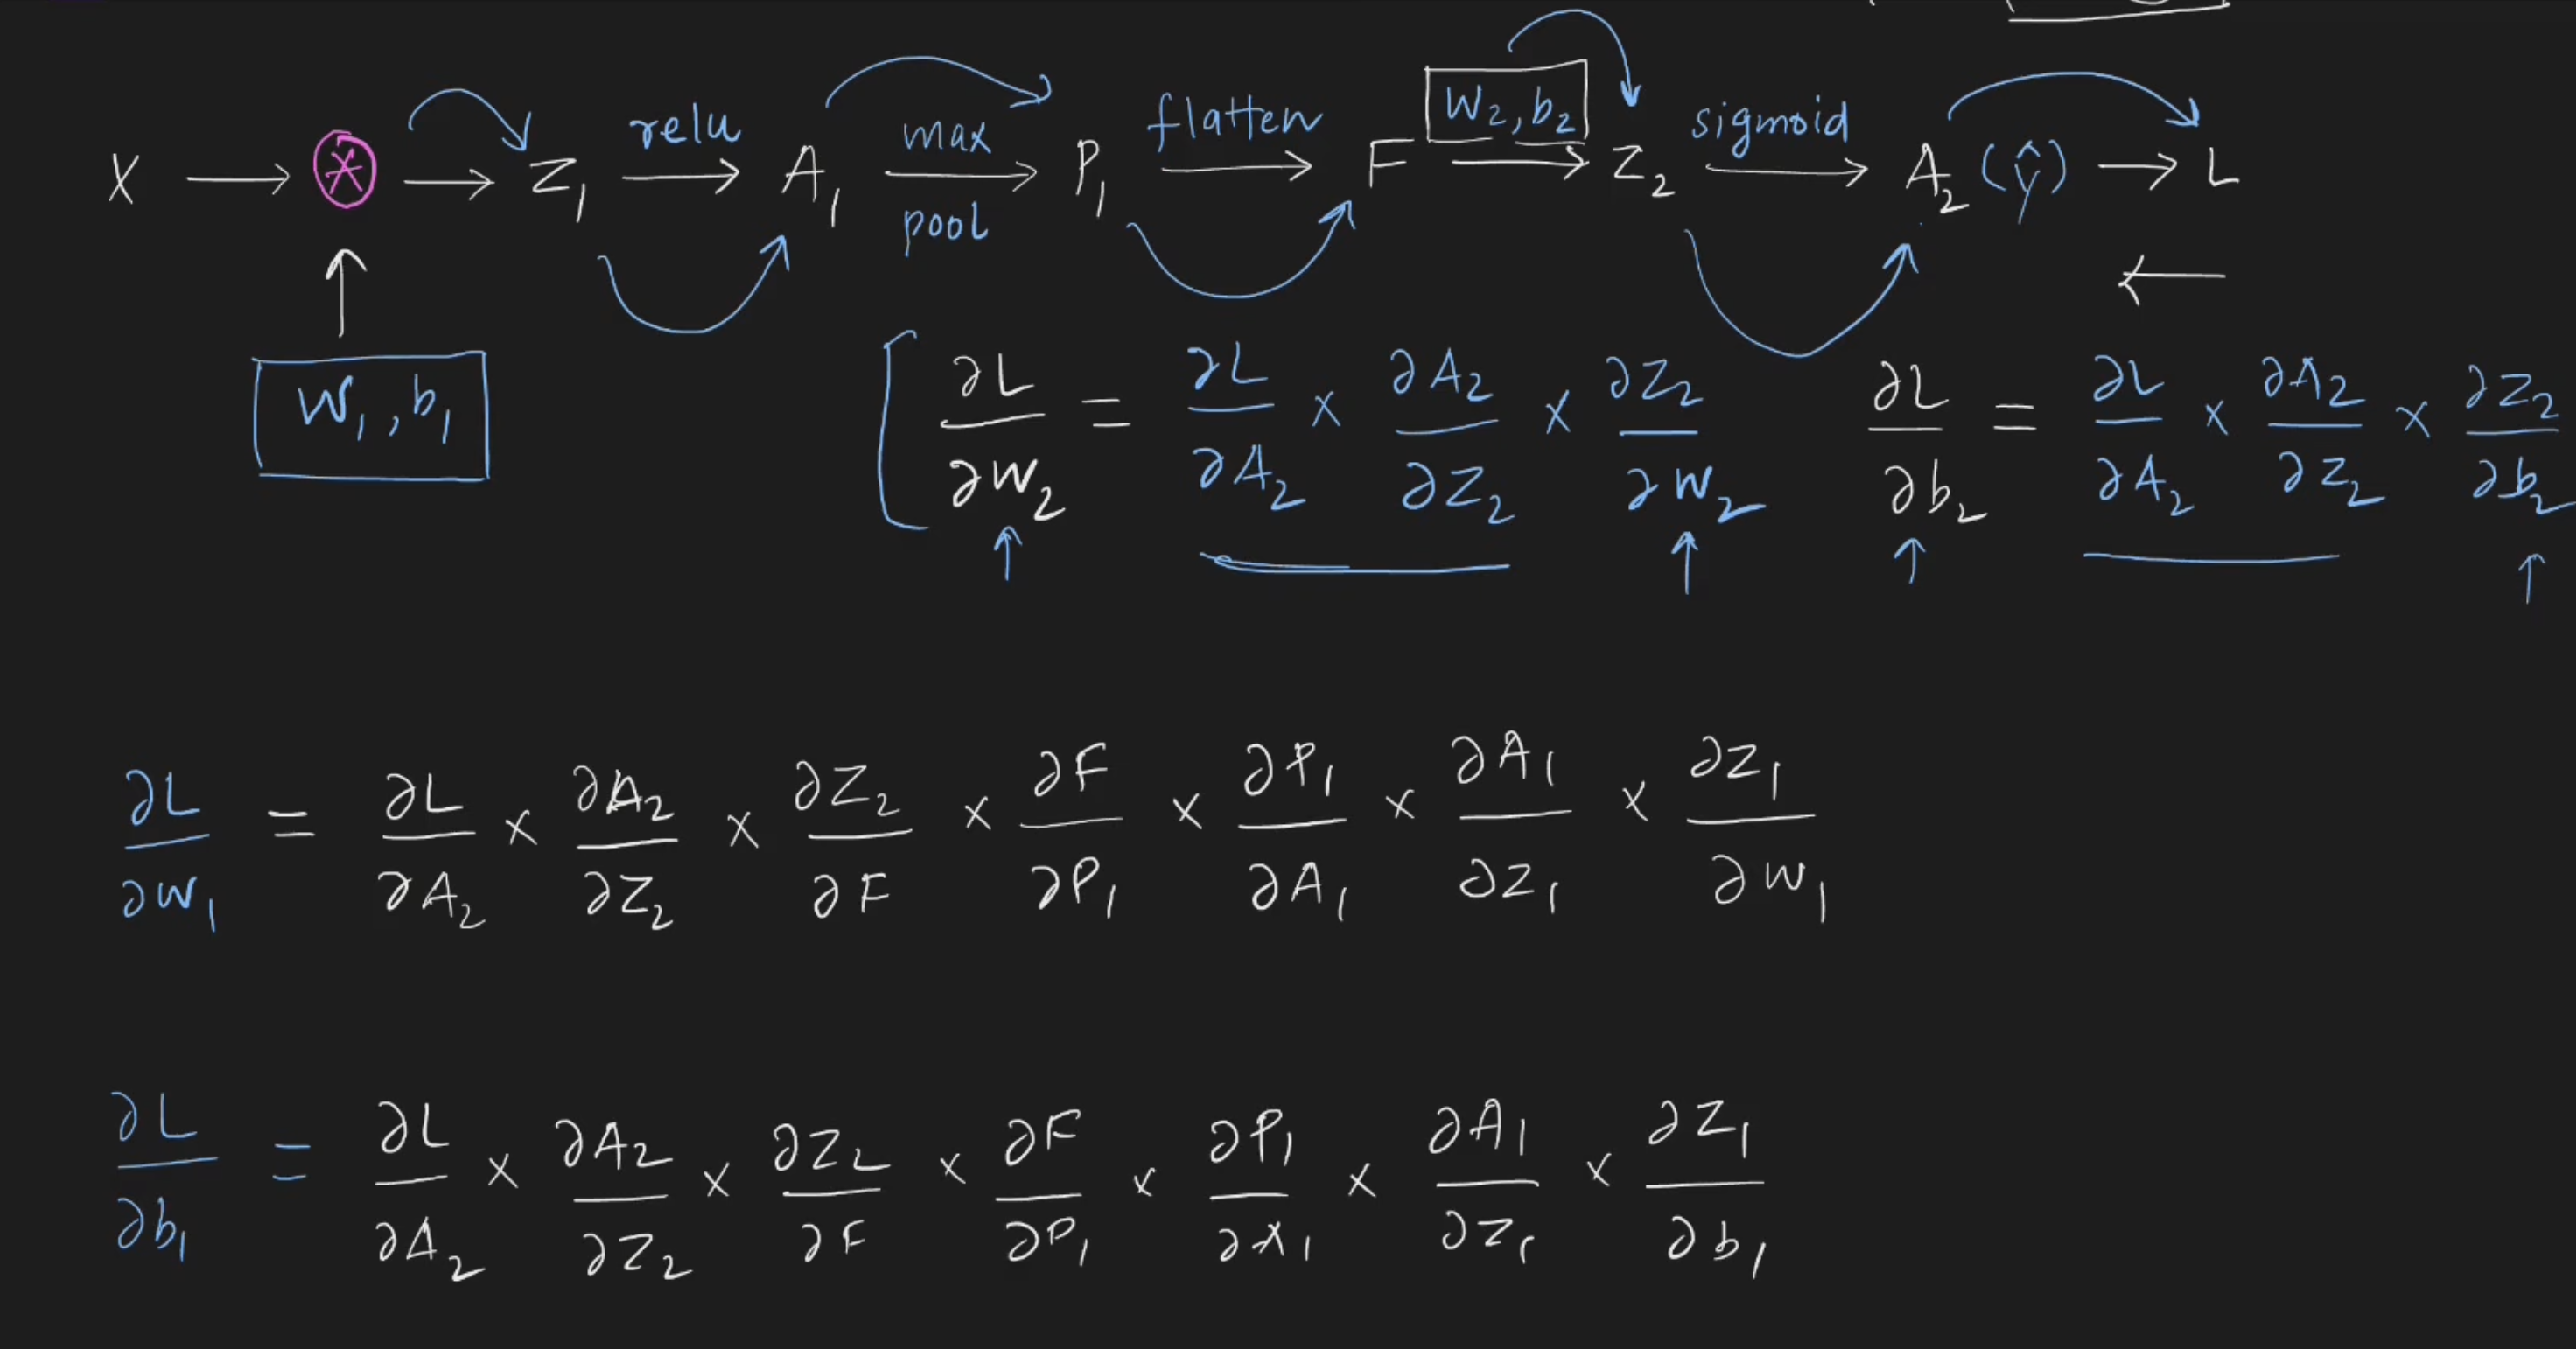

- 🔹 Backpropagation = calculating derivatives of loss w.r.t. all parameters
- 🔹 Derivatives tell us how much loss changes when we change each parameter
- 🔹 Parameters exist at **convolution layer** (W₁, b₁) and **FC layer** (W₂, b₂)
- 🔹 Forward flow: X → Conv → ReLU → Pool → Flatten → FC → Sigmoid → Loss
- 🔹 Four derivatives needed: `∂L/∂W₁`, `∂L/∂b₁`, `∂L/∂W₂`, `∂L/∂b₂`
- 🔹 Use chain rule to compute derivatives (like peeling an onion layer by layer)
- 🔹 For mini-batch, average the gradients across all images in the batch
- 🔹 This video covers: `∂L/∂W₂` and `∂L/∂b₂` (FC layer)
- 🔹 Next video covers: `∂L/∂W₁` and `∂L/∂b₁` (convolution + pooling layers)

---



# Topic 2: Backpropagation for the Fully Connected Layer (Derivatives w.r.t. W₂ and b₂)
(just check my handwritten notes)
---

## 1. Introduction

**What it is:**
Now we calculate the derivatives of the loss function with respect to the weights (W₂) and bias (b₂) of the final fully connected layer. These derivatives tell us how to update these parameters to reduce the prediction error.

**Why it's important:**
This is the "easy" part of CNN backpropagation. Once you understand this, you can apply the same logic to any standard neural network layer. It builds the foundation for understanding the more complex convolution and pooling derivatives that come next.

**Real-life use:**
Whenever you have a dense/flatten layer at the end of any CNN (which is almost always the case for classification), these exact calculations are happening thousands of times per training epoch.

---

## 2. Detailed Explanation

### 2.1 Our Goal
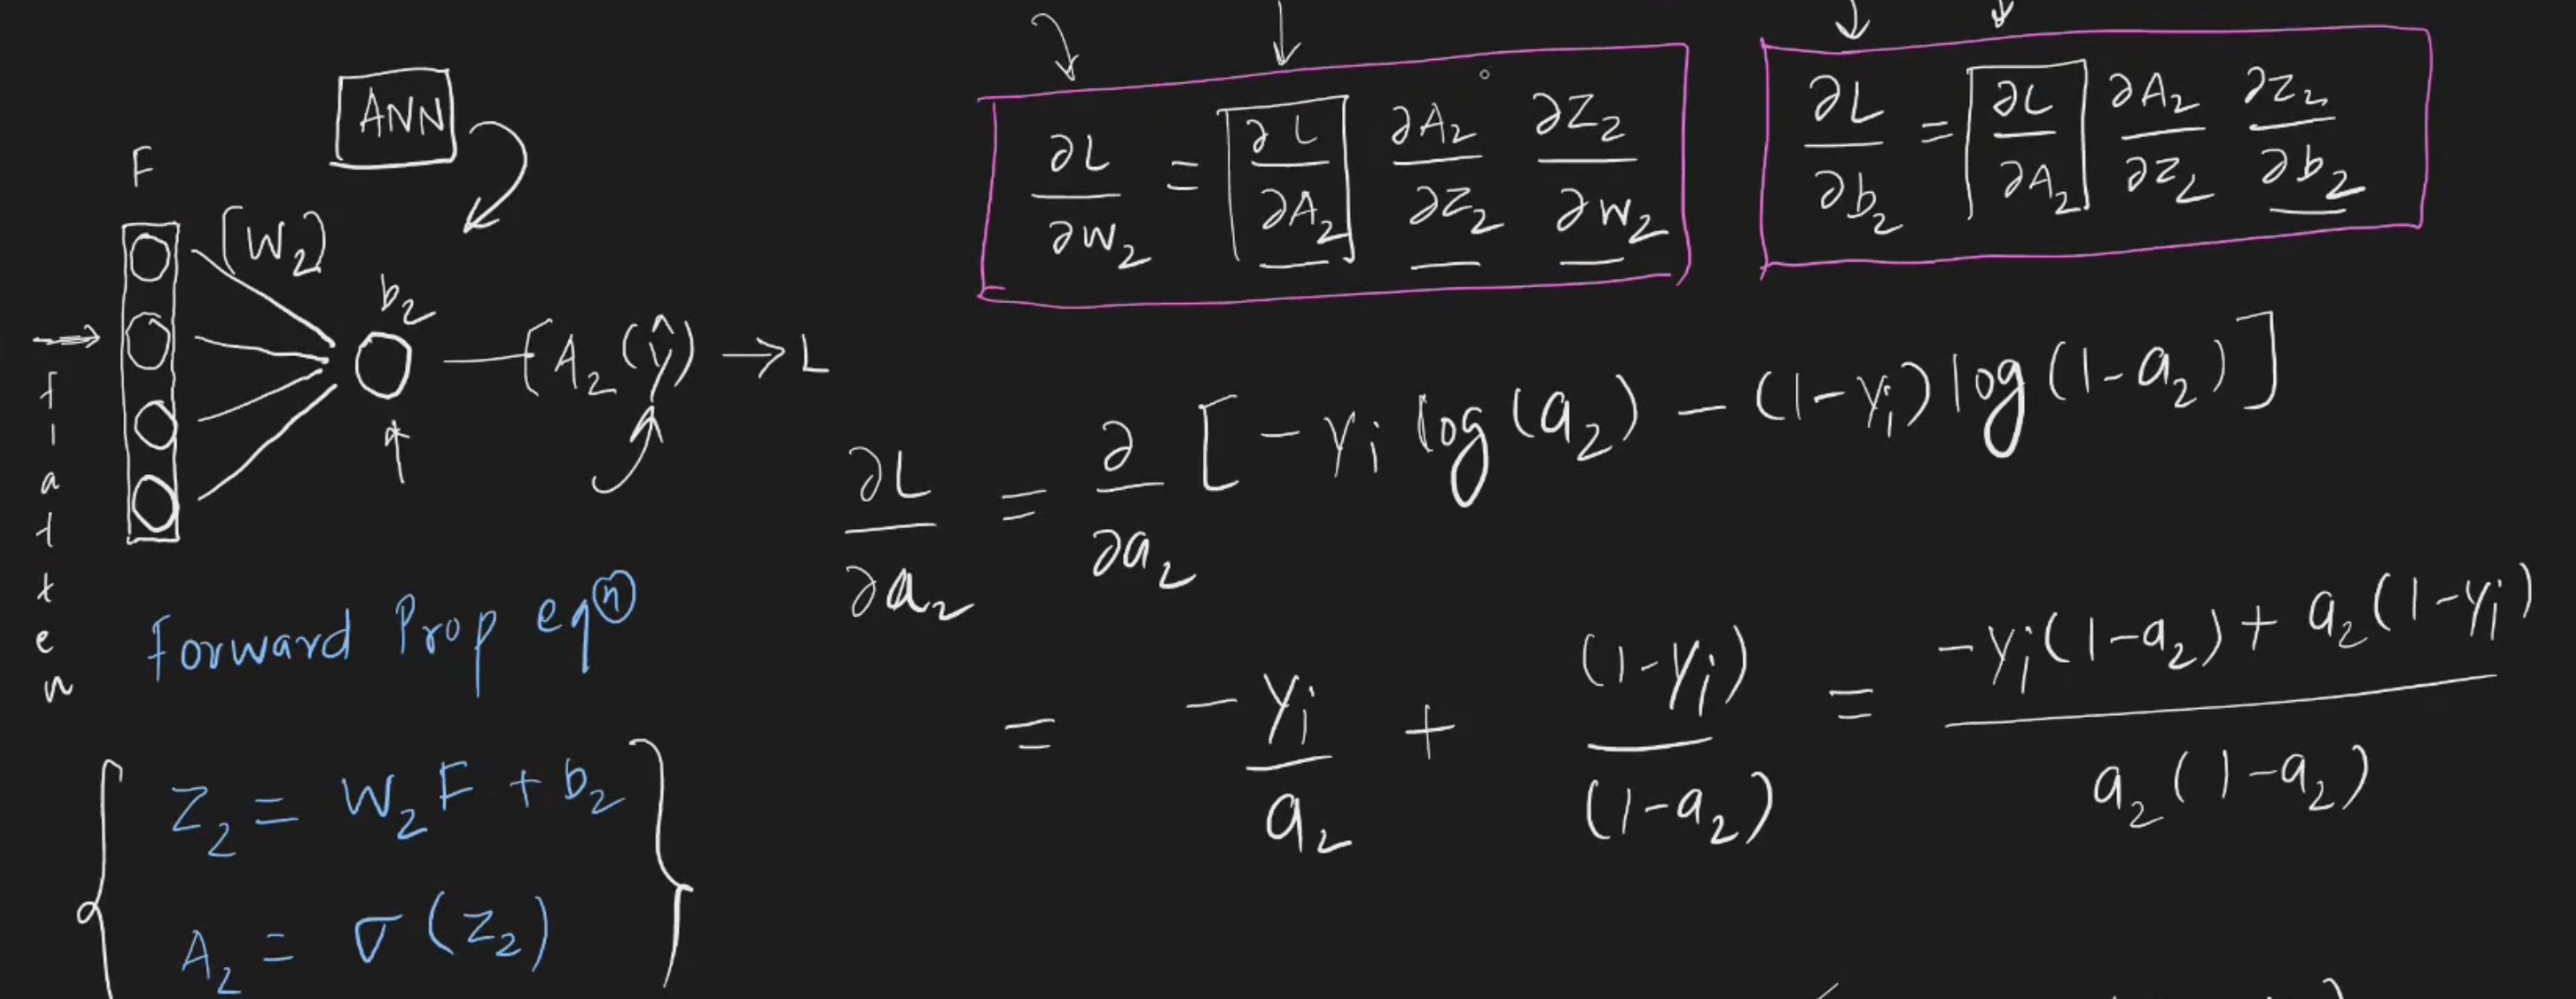
We need to calculate **four derivatives** to update all trainable parameters:

| Derivative | What it tells us | Status |
|------------|------------------|--------|
| ∂L/∂W₂ | How loss changes when FC weights change | ✅ This video |
| ∂L/∂b₂ | How loss changes when FC bias changes | ✅ This video |
| ∂L/∂W₁ | How loss changes when filter weights change | ❌ Next video |
| ∂L/∂b₁ | How loss changes when filter bias changes | ❌ Next video |

### 2.2 The Chain Rule for W₂

To find ∂L/∂W₂, we trace the path of influence:

```
Change in W₂ → Change in Z₂ → Change in A₂ → Change in L
```

Using the chain rule:

```
∂L/∂W₂ = (∂L/∂A₂) · (∂A₂/∂Z₂) · (∂Z₂/∂W₂)
```

**Where:**
- **W₂** = weight matrix of the fully connected layer (shape: 4×1)
- **Z₂** = pre-activation output (F·W₂ + b₂)
- **A₂** = final prediction (sigmoid of Z₂)
- **L** = binary cross-entropy loss

### 2.3 Step-by-Step Derivative Calculation

#### Step 1: Find ∂L/∂A₂ (Loss derivative w.r.t. prediction)

For binary cross-entropy loss on a **single image**:

```
L = -[y·log(A₂) + (1-y)·log(1-A₂)]
```

The derivative is:

```
∂L/∂A₂ = (A₂ - y) / (A₂·(1-A₂))
```

#### Step 2: Find ∂A₂/∂Z₂ (Derivative of sigmoid)

For sigmoid activation `A₂ = σ(Z₂)`:

```
∂A₂/∂Z₂ = A₂·(1-A₂)
```

#### Step 3: Multiply the first two terms (∂L/∂Z₂)

```
∂L/∂Z₂ = (∂L/∂A₂) · (∂A₂/∂Z₂)
       = [ (A₂ - y) / (A₂·(1-A₂)) ] · [ A₂·(1-A₂) ]
       = A₂ - y
```

> 💡 **Key Result:** `∂L/∂Z₂ = A₂ - y` (for a single image)

#### Step 4: Find ∂Z₂/∂W₂

Since `Z₂ = F·W₂ + b₂`:

```
∂Z₂/∂W₂ = F
```

Where F is the flattened input vector (shape: 1×4).

#### Step 5: Combine to get ∂L/∂W₂

```
∂L/∂W₂ = (∂L/∂Z₂) · (∂Z₂/∂W₂)
       = (A₂ - y) · F
```

**For a single image:**
- `A₂ - y` is a scalar (1×1)
- `F` is a 1×4 vector
- Result: 1×4 vector (matches W₂ shape)

### 2.4 Derivative w.r.t. b₂ (Bias of FC layer)

```
∂L/∂b₂ = ∂L/∂Z₂ = A₂ - y
```

Because `∂Z₂/∂b₂ = 1`.

---

### 2.5 Shape Verification

| Variable | Shape | Notes |
|----------|-------|-------|
| W₂ | 4×1 | Trainable weights |
| b₂ | 1×1 | Trainable bias |
| F | 1×4 | Flattened input |
| Z₂ | 1×1 | Pre-activation (scalar) |
| A₂ | 1×1 | Prediction (scalar) |
| y | 1×1 | True label (scalar) |
| ∂L/∂W₂ | 1×4 | Must match W₂ shape |
| ∂L/∂b₂ | 1×1 | Must match b₂ shape |

---

### 2.6 Summary of Derivatives for FC Layer

**For a single image:**
```
∂L/∂W₂ = (A₂ - y) · F
∂L/∂b₂ = A₂ - y
```

> 🔑 **Remember:** The derivative w.r.t. weights equals the error term (`A₂ - y`) multiplied by the input to that layer.

---

## 3. Key Points

- ✅ ∂L/∂Z₂ simplifies beautifully to `A₂ - y` (prediction minus true label)
- ✅ ∂L/∂W₂ = `(A₂ - y) · F` — the input vector multiplied by the error
- ✅ ∂L/∂b₂ = `A₂ - y` — just the error term
- ✅ Shapes must match: derivative w.r.t. W₂ has same shape as W₂
- ✅ This uses the same principles as backpropagation in standard neural networks

---


---

## 5. Mini-Batch Extension

When using **mini-batch gradient descent** with M images:

| Variable | Single Image | Mini-Batch (M images) |
|----------|--------------|----------------------|
| A₂ | 1×1 | M×1 (predictions) |
| y | 1×1 | M×1 (true labels) |
| F | 1×4 | M×4 (flattened inputs) |
| Error | 1×1 | M×1 |
| ∂L/∂W₂ | 1×4 | **(1/M) · Fᵀ · error** |
| ∂L/∂b₂ | 1×1 | **(1/M) · sum(error)** |

**Mini-batch formula:**
```
∂L/∂W₂ = (1/M) · Fᵀ · (A₂ - y)
∂L/∂b₂ = (1/M) · Σ(A₂ - y)
```

> ⚠️ **Important:** The shape of ∂L/∂W₂ remains **1×4** regardless of batch size (it must match the weight shape).

---

## 6. Common Mistakes

| ❌ Mistake | ✅ Correction |
|------------|---------------|
| Forgetting to divide by M in mini-batch | Always average gradients over the batch |
| Mixing up shape of F (4×1 vs 1×4) | F is 1×4; W₂ is 4×1; their product is scalar |
| Using ∂L/∂A₂ directly without multiplying by sigmoid derivative | The chain rule requires both terms, but they cancel out conveniently |
| Not verifying shapes match | ∂L/∂W₂ must have same shape as W₂ |
| Forgetting that A₂, y, and error are scalars in single-image case | This makes matrix multiplication simpler |

---

## 7. Interview/Exam Questions

**Q1: Derive ∂L/∂W₂ for a binary classification CNN with a fully connected output layer.**

**A:**

```
L = -[y·log(A₂) + (1-y)·log(1-A₂)]
A₂ = σ(Z₂) where Z₂ = F·W₂ + b₂

∂L/∂W₂ = (∂L/∂A₂) · (∂A₂/∂Z₂) · (∂Z₂/∂W₂)
        = [(A₂-y)/(A₂(1-A₂))] · [A₂(1-A₂)] · F
        = (A₂-y) · F
```

---

**Q2: Why does ∂L/∂Z₂ simplify to A₂ - y?**

**A:** Because the derivative of binary cross-entropy w.r.t. sigmoid output and the derivative of sigmoid cancel each other out:
- ∂L/∂A₂ = (A₂-y)/(A₂(1-A₂))
- ∂A₂/∂Z₂ = A₂(1-A₂)
- Product = A₂-y

This is one of the beautiful simplifications in deep learning.

---

**Q3: How do the formulas change when using mini-batch gradient descent?**

**A:**

For M images:
- ∂L/∂W₂ = (1/M) · Fᵀ · (A₂ - y)
- ∂L/∂b₂ = (1/M) · Σ(A₂ - y)

Where F is M×4, and (A₂-y) is M×1.

---

**Q4: What is the shape of ∂L/∂W₂ and why must it match W₂'s shape?**

**A:** ∂L/∂W₂ has shape 1×4, matching W₂'s shape. This is necessary because we update W₂ as:
`W₂_new = W₂ - learning_rate × ∂L/∂W₂`
Both must have identical dimensions for element-wise subtraction.

---

## 8. Revision Notes

- 🔹 ∂L/∂W₂ = (A₂ - y) · F (single image)
- 🔹 ∂L/∂b₂ = A₂ - y (single image)
- 🔹 For mini-batch: average the gradients over M samples
- 🔹 Error term = prediction - true label = A₂ - y
- 🔹 Shape of ∂L/∂W₂ must match W₂'s shape
- 🔹 This is the "easy" part — next video covers convolution derivatives
- 🔹 ∂L/∂Z₂ = A₂ - y is a key intermediate result

---



# Topic 3: Backpropagation for Convolution and Pooling Layers – The Challenge

---

## 1. Introduction

**What it is:**
Now we tackle the hardest part of CNN backpropagation: calculating derivatives with respect to the **convolution filter weights (W₁)** and **bias (b₁)** . Unlike the fully connected layer, convolution involves spatial operations, weight sharing, and local receptive fields. Plus, we need to handle the **max pooling** layer, which has no trainable parameters but still affects gradient flow.

**Why it's important:**
The convolution layer is where the CNN learns to detect features like edges, textures, and patterns. Understanding how gradients flow back through this layer helps you:
- Debug why certain filters don't learn
- Make better decisions about filter sizes, strides, and padding
- Understand advanced techniques like transposed convolutions (used in GANs and autoencoders)

**Real-life use:**
Every time a CNN learns to detect a cat's ear, a car's wheel, or a tumor in a medical scan, these convolution derivatives are at work, tuning the filter weights to activate on the right patterns.

**⚠️ Advanced Topic Ahead:**
This section covers the most complex part. The instructor emphasized that this is rarely covered in textbooks and requires **multiple viewings** with pen and paper.

